# ![Machine Learning Lab](banner.jpg)

# Laboratorio 9 - Actividad

## Instrucciones generales

1. Esta actividad es de carácter individual. No se permite entregar la actividad después de la fecha establecida.
2. Al responder las preguntas de las actividades, por favor marquen las respuestas con la sección a la que corresponden, por ejemplo: `## 1.1 Carga de datos`. Es preferible que esto lo hagan con secciones de MarkDown.
3. Por favor asegurarse de que el notebook entregado tenga todas las celdas ejecutadas correctamente.
4. Por favor, nombren el archivo de acuerdo con el siguiente formato `{email}_lab9.ipynb`.
5. Si tienen alguna duda, pueden escribirme a mi correo `j.rayom@uniandes.edu.co` o contactarme directamente por Teams.

---

## Objetivos

1. Construir y entrenar una CNN desde cero para clasificación de imágenes de mariposas.
2. Aplicar transferencia de aprendizaje utilizando un modelo preentrenado en ImageNet.
3. Comparar el desempeño de ambos enfoques y analizar las ventajas del transfer learning en escenarios con datos limitados.

---

En esta ocasión trabajaremos con el dataset **Butterfly Image Classification**, que contiene imágenes de distintas especies de mariposas. Para esta actividad, **deberán usar únicamente un subconjunto reducido del dataset original** (máximo 200 imágenes por clase, seleccionando solo 10 clases) para simular un escenario con datos limitados.

Dataset: [Butterfly Image Classification](https://www.kaggle.com/datasets/phucthaiv02/butterfly-image-classification)

---

## Instrucciones

### 1. Carga y exploración de datos (10%)

1. Descarga el dataset utilizando `kagglehub`:
   ```python
   import kagglehub
   path = kagglehub.dataset_download('phucthaiv02/butterfly-image-classification')
   ```
2. Explora la estructura de carpetas del dataset y cuenta el número de imágenes por clase.
3. Selecciona **10 clases** del dataset y toma un máximo de **200 imágenes por clase**. Copia estas imágenes a una carpeta organizada para trabajar con el subconjunto.
4. Visualiza al menos 2 imágenes de ejemplo de cada clase seleccionada en una cuadrícula.
5. Muestra la distribución de clases del subconjunto en un gráfico de barras.

---

### 2. Preprocesamiento de datos (15%)

1. Redimensiona todas las imágenes a **224×224 píxeles**.
2. Normaliza los valores de los píxeles al rango [0, 1].
3. Divide el dataset en conjuntos de entrenamiento (70%), validación (15%) y prueba (15%). Utiliza `seed = 42`.
4. Crea los datasets de TensorFlow/Keras utilizando `image_dataset_from_directory`.

---

### 3. CNN (25%)

1. Construye una CNN con al menos **3 bloques convolucionales** (Conv2D + MaxPooling2D) seguidos de capas Dense para la clasificación.
2. Muestra el resumen del modelo (`model.summary()`) e indica el número total de parámetros.
3. Compila el modelo con optimizador Adam y función de pérdida adecuada para clasificación multiclase.
4. Entrena el modelo por al menos **20 épocas**.
5. Grafica las curvas de pérdida y precisión (entrenamiento vs validación).
6. Evalúa el modelo en el conjunto de prueba.

---

### 4. Transfer Learning con Fine-Tuning (35%)

1. Carga el modelo **MobileNetV2** preentrenado en ImageNet **sin la capa de clasificación** (`include_top=False`).
2. Congela todas las capas del modelo base.
3. Agrega un clasificador personalizado encima del modelo base.
4. **Feature Extraction**: Entrena solo las capas del clasificador por al menos **10 épocas**.
5. **Fine-Tuning**: Descongela las últimas 30 capas del modelo base y entrena con un learning rate bajo por al menos **10 épocas** adicionales.
6. Grafica las curvas de pérdida y precisión para ambas fases.
7. Evalúa el modelo final en el conjunto de prueba.

---

### 5. Comparación de resultados (15%)

1. Genera la **matriz de confusión** para ambos modelos (CNN y Transfer Learning).
2. Reporta la **precisión (accuracy)**, **precision por clase** y **recall por clase** para ambos modelos.
3. ¿El modelo con transfer learning supera al CNN entrenado desde cero? ¿Por qué crees que sucede esto?
4. ¿Cuáles especies de mariposa son más difíciles de clasificar en cada modelo?

---


In [132]:
# librerías
import os
import sys
from pathlib import Path
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import shutil
from tqdm import tqdm


In [133]:
# cargar los datos
path = kagglehub.dataset_download('phucthaiv02/butterfly-image-classification')

Using Colab cache for faster access to the 'butterfly-image-classification' dataset.


In [134]:
# listar archivos y carpetas en la raíz del dataset
path = Path(path)
root_files = [f for f in path.iterdir() if f.is_file()]
root_folders = [d for d in path.iterdir() if d.is_dir()]
print(f"Archivos en la carpeta: {[f.name for f in root_files]}")
print(f"Subcarpetas en la carpeta: {[d.name for d in root_folders]}")

Archivos en la carpeta: ['Training_set.csv', 'Testing_set.csv']
Subcarpetas en la carpeta: ['test', 'train']


In [135]:
# guardar la ruta de la carpeta de entrenamiento y test
train_path = path / 'train'
test_path = path / 'test'

# obtener número de archivos en cada carpeta
print(f"\nNúmero de archivos en 'train': {len(list(train_path.rglob('*.*')))}")
print(f"Número de archivos en 'test': {len(list(test_path.rglob('*.*')))}")


Número de archivos en 'train': 6499
Número de archivos en 'test': 2786


**Nota:** las etiquetas del conjunto de prueba se encuentran en el archivo `Training_set.csv`.

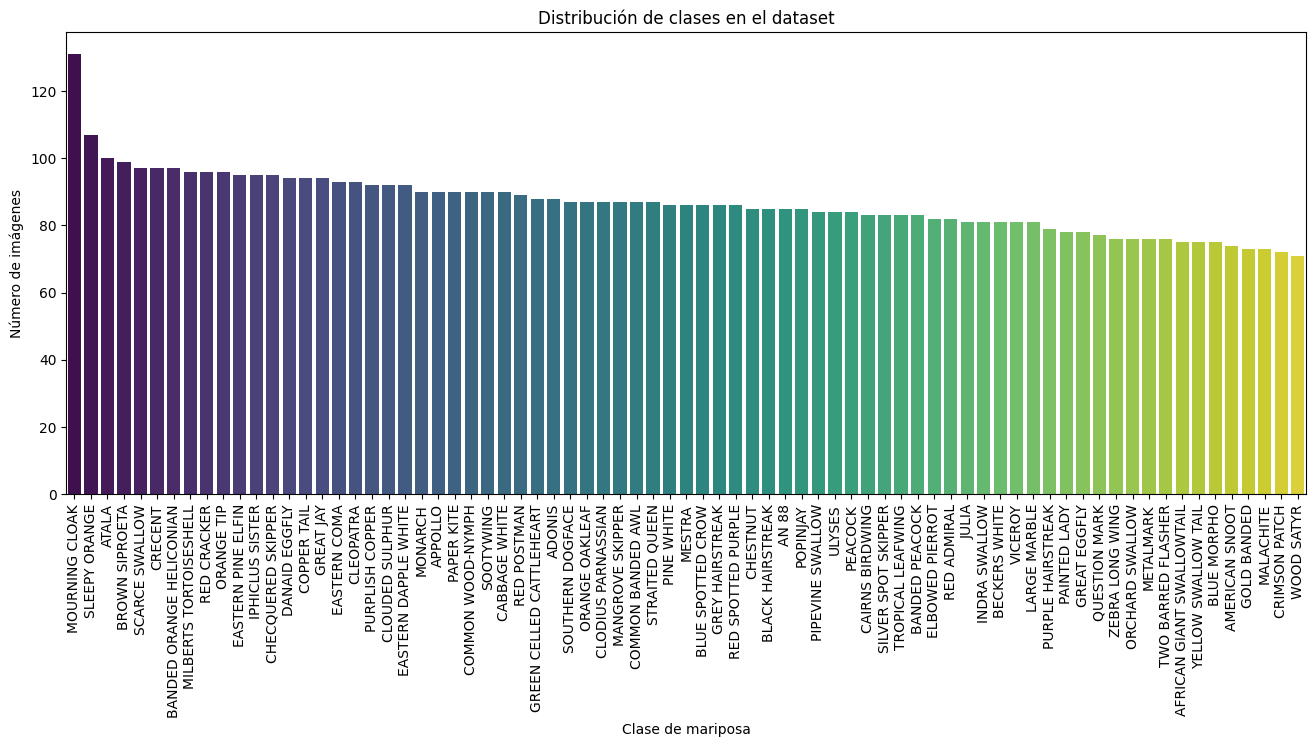

In [136]:
# explorar los archivos csv
train_df = pd.read_csv(path / 'Training_set.csv')
test_df = pd.read_csv(path / 'Testing_set.csv')

# train_df tiene todas las imagenes (de train y test) etiquetadas. Se añade una columna 'set' para identificar a qué conjunto pertenece cada imagen
train_df['set'] = train_df['filename'].apply(lambda x: 'test' if x in test_df['filename'].values else 'train')

# plotear la distribución de clases
plt.figure(figsize=(16, 6))
sns.countplot(data=train_df, x='label', order=train_df['label'].value_counts().index, palette='viridis')
plt.xticks(rotation=90)
plt.title('Distribución de clases en el dataset')
plt.xlabel('Clase de mariposa')
plt.ylabel('Número de imágenes')
plt.show()

El dataset está separado en dos carpetas principales, train y test. Cada carpeta contiene imágenes de todas las clases de mariposas. En el directorio base hay además dos archivos CSV con información sobre las etiquetas de las imágenes. Podemos observar que hay una clase mayoritaria (Mourning Cloak) con más de 120 imágenes, mientras que el resto de clases tienen entre 80 y 100 aproximadamente.

Se seleccionarán 10 clases al azar (con un random state fijo para que sea reproducible). Como ninguna clase tiene más de 200 imágenes, no se aplican filtros extra.

Clases seleccionadas aleatoriamente: ['QUESTION MARK' 'COPPER TAIL' 'ADONIS' 'JULIA' 'DANAID EGGFLY'
 'EASTERN PINE ELFIN' 'CLEOPATRA' 'BLUE SPOTTED CROW' 'ORANGE TIP' 'AN 88']
Total imágenes filtradas: 889


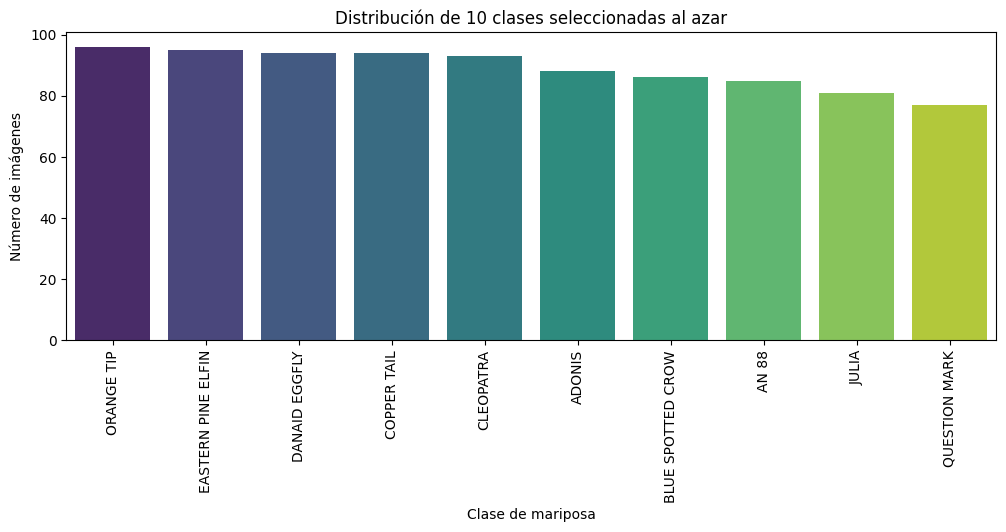

In [137]:
# 10 clases al azar
all_classes = train_df['label'].unique()
selected_classes = pd.Series(all_classes).sample(n=10, random_state=2).values

# filtrar el dataframe con estas 10 clases aleatorias
filtered_df = train_df[train_df['label'].isin(selected_classes)]

print(f"Clases seleccionadas aleatoriamente: {selected_classes}")
print(f"Total imágenes filtradas: {len(filtered_df)}")

# plot de la distribución de las clases seleccionadas
plt.figure(figsize=(12, 4))
sns.countplot(data=filtered_df, x='label',
              order=filtered_df['label'].value_counts().index,
              palette='viridis')
plt.xticks(rotation=90)
plt.title(f'Distribución de 10 clases seleccionadas al azar')
plt.xlabel('Clase de mariposa')
plt.ylabel('Número de imágenes')
plt.show()

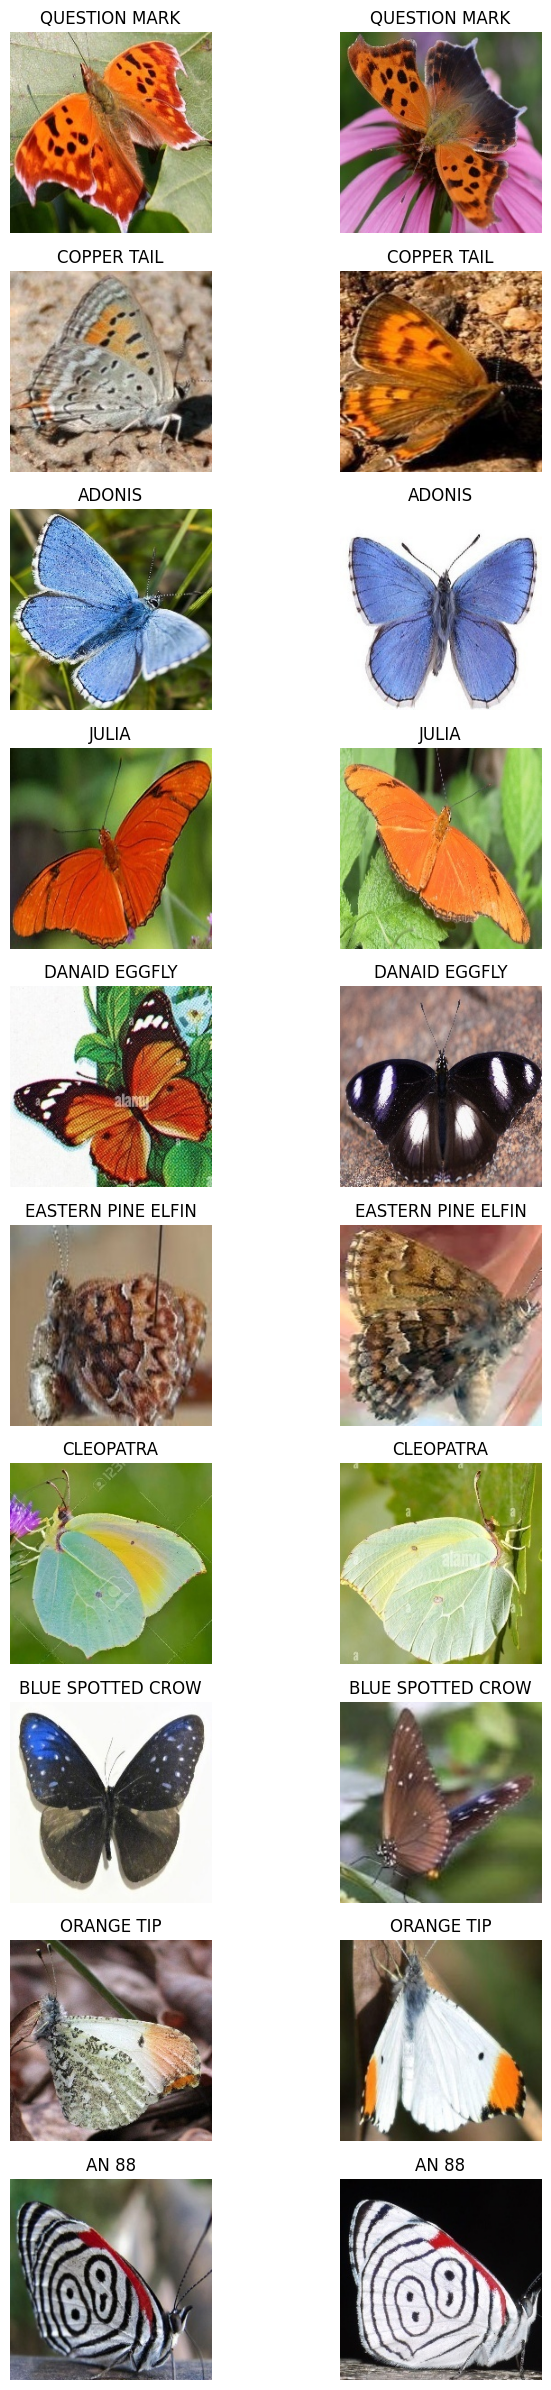

In [138]:
# visualización de 2 imágenes por clase
plt.figure(figsize=(8, 24))
for i, cls in enumerate(selected_classes):
    cls_images = filtered_df[filtered_df['label'] == cls]['filename'].values[:2]
    for j, img in enumerate(cls_images):
        img_path = train_path / img
        if img_path.exists():
            img_data = plt.imread(img_path)
            plt.subplot(10, 2, i*2 + j + 1)
            plt.imshow(img_data)
            plt.title(cls)
            plt.axis('off')
plt.tight_layout()
plt.show()

In [139]:
# copiar las imagenes seleccionadas en una carpeta
full_data_path = Path('full_data')
full_data_path.mkdir(parents=True, exist_ok=True)

# iterar sobre el df filtrado
for _, row in tqdm(filtered_df.iterrows(), total=filtered_df.shape[0]):
    # carpeta de origen
    folder_name = 'train' if row['set'] == 'train' else 'test'
    src_path = Path(path) / folder_name / row['filename']

    # carpeta de destino (nombre de la categoría)
    dest_dir = full_data_path / str(row['label'])
    dest_dir.mkdir(parents=True, exist_ok=True)
    dest_path = dest_dir / row['filename']

    # copiar la imagen
    if src_path.exists():
        shutil.copy(src_path, dest_path)
    else:
        alt_path = Path(path) / row['filename']
        if alt_path.exists():
            shutil.copy(alt_path, dest_path)
        else:
            print(f"No se encontró la imagen: {row['filename']}")

100%|██████████| 889/889 [00:00<00:00, 1060.89it/s]


### 2. Preprocesamiento de datos (15%)

1. Redimensiona todas las imágenes a **224×224 píxeles**.
2. Normaliza los valores de los píxeles al rango [0, 1].
3. Divide el dataset en conjuntos de entrenamiento (70%), validación (15%) y prueba (15%). Utiliza `seed = 42`.
4. Crea los datasets de TensorFlow/Keras utilizando `image_dataset_from_directory`.

In [140]:
# definir variables útiles
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32

# carga de dataset con keras
train_ds = tf.keras.utils.image_dataset_from_directory(
    full_data_path,
    validation_split=0.3,
    subset='training',
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    full_data_path,
    validation_split=0.3,
    subset='validation',
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Dividir validación y test
val_size = int(0.5 * len(val_test_ds))
val_ds = val_test_ds.take(val_size)
test_ds = val_test_ds.skip(val_size)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f'Clases: {class_names}')
print(f'Número de clases: {num_classes}')

Found 889 files belonging to 10 classes.
Using 623 files for training.
Found 889 files belonging to 10 classes.
Using 266 files for validation.
Clases: ['ADONIS', 'AN 88', 'BLUE SPOTTED CROW', 'CLEOPATRA', 'COPPER TAIL', 'DANAID EGGFLY', 'EASTERN PINE ELFIN', 'JULIA', 'ORANGE TIP', 'QUESTION MARK']
Número de clases: 10


In [141]:
# normalizar los datos - se usa el rango -1 a 1 porque sirve tanto para cnn como mobile net
normalization_layer = layers.Rescaling(1./127.5, offset=-1)

train_ds_norm = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds_norm = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds_norm = test_ds.map(lambda x, y: (normalization_layer(x), y))

# optimizar rendimiento con prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds_norm = train_ds_norm.prefetch(buffer_size=AUTOTUNE)
val_ds_norm = val_ds_norm.prefetch(buffer_size=AUTOTUNE)
test_ds_norm = test_ds_norm.prefetch(buffer_size=AUTOTUNE)

In [142]:
# comprobar el tamaño de una imagen para conocer el número de canales
img_path = train_path / filtered_df.iloc[0]['filename']
img = tf.keras.preprocessing.image.load_img(img_path)
img_array = tf.keras.preprocessing.image.img_to_array(img)
print(f"Tamaño de la imagen: {img_array.shape}")

Tamaño de la imagen: (224, 224, 3)



### 3. CNN (25%)

1. Construye una CNN con al menos **3 bloques convolucionales** (Conv2D + MaxPooling2D) seguidos de capas Dense para la clasificación.
2. Muestra el resumen del modelo (`model.summary()`) e indica el número total de parámetros.
3. Compila el modelo con optimizador Adam y función de pérdida adecuada para clasificación multiclase.
4. Entrena el modelo por al menos **20 épocas**.
5. Grafica las curvas de pérdida y precisión (entrenamiento vs validación).
6. Evalúa el modelo en el conjunto de prueba.

In [143]:
# construir la red convolucional
# modelo
cnn_model = tf.keras.Sequential([
    # capas convolucionales
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)), # las imágenes son de 3 canales
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # clasificación
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

cnn_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,177,866 (42.64 MB)

 Trainable params: 11,177,866 (42.64 MB)

 Non-trainable params: 0 (0.00 B)

Podemos observar que el número total de parámetros entrenables es 11,170,250.

El modelo es compilado con la función de pérdida categorical_corssentropy, pues se está trabajando con un problema de clasificación multiclase. La métrica usada para medir el rendimiento será accuracy, pues todas las clases tienen la misma importancia.

In [144]:
# compilación del modelo
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

A continuación se implementarán algunos callbacks para evitar el sobreajuste y obtener el modelo con los mejores pesos, es decir, el modelo que mejore la pérdida en el conjunto de validación.

In [145]:
# checkpoint del modelo
model_checkpoint = ModelCheckpoint('best_model.h5',
                                   save_best_only=True,
                                   monitor='val_loss',
                                   mode='min')

# early stopping
early_stopping = EarlyStopping(monitor='val_loss',
                               patience=15,
                               verbose=1,
                               restore_best_weights=True,
                               mode='min')

# reducción del lr
reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.1,
                              patience=5,
                              verbose=1,
                              min_lr=1e-6,
                              mode='min')

callbacks = [model_checkpoint, early_stopping, reduce_lr]

with tf.device('/device:GPU:0'):
    history = cnn_model.fit(
        train_ds_norm,
        validation_data=val_ds_norm,
        epochs=50,
        callbacks=callbacks
    )

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.0858 - loss: 2.7918

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 240ms/step - accuracy: 0.1011 - loss: 2.5007 - val_accuracy: 0.0703 - val_loss: 2.3038 - learning_rate: 0.0010
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.1529 - loss: 2.2006

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.1621 - loss: 2.1992 - val_accuracy: 0.2578 - val_loss: 2.2476 - learning_rate: 0.0010
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2024 - loss: 2.1037

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - accuracy: 0.2263 - loss: 2.1212 - val_accuracy: 0.2891 - val_loss: 2.1938 - learning_rate: 0.0010
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.3002 - loss: 2.0039 - val_accuracy: 0.2812 - val_loss: 2.2255 - learning_rate: 0.0010
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.3788 - loss: 1.8719 - val_accuracy: 0.2578 - val_loss: 2.2928 - learning_rate: 0.0010
Epoch 6/50
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3839 - loss: 1.7591

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.4077 - loss: 1.7215 - val_accuracy: 0.3281 - val_loss: 2.1179 - learning_rate: 0.0010
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.5409 - loss: 1.4005 - val_accuracy: 0.3203 - val_loss: 2.2911 - learning_rate: 0.0010
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.6404 - loss: 1.1240 - val_accuracy: 0.2891 - val_loss: 2.5319 - learning_rate: 0.0010
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.7640 - loss: 0.7723 - val_accuracy: 0.3281 - val_loss: 2.8988 - learning_rate: 0.0010
Epoch 10/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.8250 - loss: 0.5466 - val_accuracy: 0.3047 - val_loss: 4.1449 - learning_rate: 0.0010
Epoch 11/50
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8823 - loss: 0.3821
Epoch 11: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.9005 - loss: 0.3531 - val_accuracy: 0

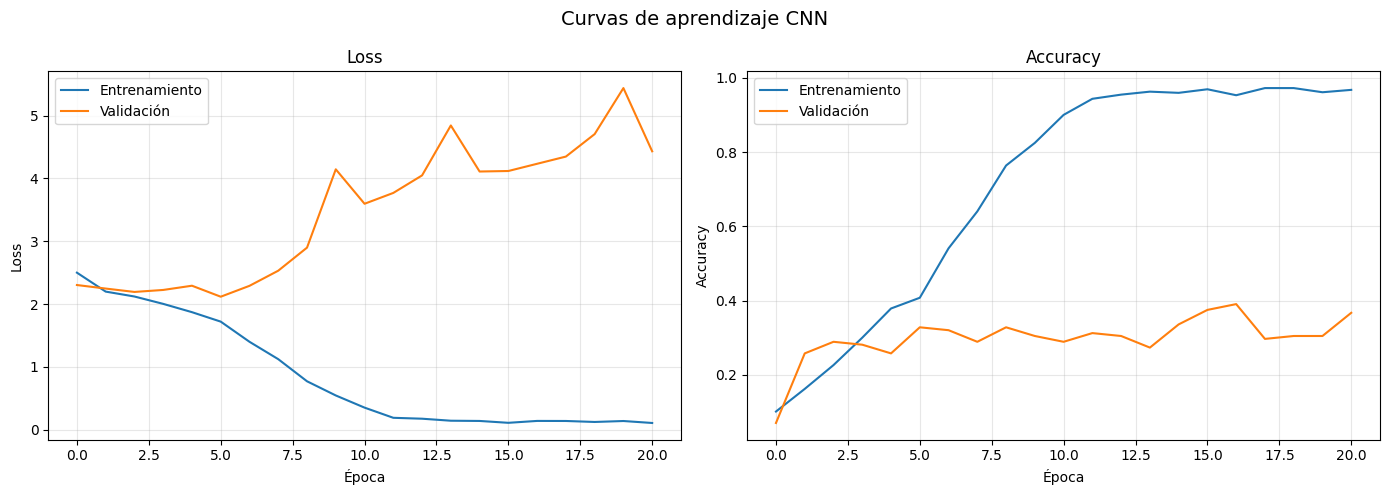

In [146]:
# graficar curvas de pérdida y precisión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], label='Entrenamiento')
ax1.plot(history.history['val_loss'], label='Validación')
ax1.set_title('Loss')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['accuracy'], label='Entrenamiento')
ax2.plot(history.history['val_accuracy'], label='Validación')
ax2.set_title('Accuracy')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Curvas de aprendizaje CNN', fontsize=14)
plt.tight_layout()
plt.show()

En las gráficas de entrenamiento se puede observar un sobreajuste del modelo. Gracias a los callbacks usados, se evita tomar los pesos del modelo ya sobreajustados.

In [147]:
# obtener el accuracy en test
test_loss, test_acc = cnn_model.evaluate(test_ds_norm)
print(f'Accuracy en el conjunto de prueba: {test_acc}')

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.2681 - loss: 2.4855
Accuracy en el conjunto de prueba: 0.26811593770980835


### 4. Transfer Learning con Fine-Tuning (35%)

1. Carga el modelo **MobileNetV2** preentrenado en ImageNet **sin la capa de clasificación** (`include_top=False`).
2. Congela todas las capas del modelo base.
3. Agrega un clasificador personalizado encima del modelo base.
4. **Feature Extraction**: Entrena solo las capas del clasificador por al menos **10 épocas**.
5. **Fine-Tuning**: Descongela las últimas 30 capas del modelo base y entrena con un learning rate bajo por al menos **10 épocas** adicionales.
6. Grafica las curvas de pérdida y precisión para ambas fases.
7. Evalúa el modelo final en el conjunto de prueba.

Primero se entrena el modelo con la cabeza de clasificación.

In [148]:
# cargar el modelo
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

print(f'Número de capas en MobileNetV2: {len(base_model.layers)}')
print(f'Forma de la salida del modelo base: {base_model.output_shape}')

Número de capas en MobileNetV2: 154
Forma de la salida del modelo base: (None, 7, 7, 1280)


In [149]:
# congelar todas las capas del modelo base
base_model.trainable = False

# agregar un clasificador - feature extraction
feature_extraction_model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
], name='feature_extraction_model')

feature_extraction_model.summary()

Model: "feature_extraction_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [150]:
# Compilar y entrenar
feature_extraction_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Entrenando con Feature Extraction...')
fe_history = feature_extraction_model.fit(
    train_ds_norm,
    validation_data=val_ds_norm,
    epochs=15,
    verbose=1
)

Entrenando con Feature Extraction...
Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 576ms/step - accuracy: 0.2568 - loss: 2.2605 - val_accuracy: 0.5156 - val_loss: 1.7114
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.5088 - loss: 1.6382 - val_accuracy: 0.5312 - val_loss: 1.5852
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.5682 - loss: 1.4375 - val_accuracy: 0.5781 - val_loss: 1.4676
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.6132 - loss: 1.2652 - val_accuracy: 0.5859 - val_loss: 1.4344
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.6549 - loss: 1.1433 - val_accuracy: 0.6172 - val_loss: 1.5021
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6838 - loss: 1.0276 - val_accuracy: 0.5781 - val_loss: 1.6318
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7303 - loss: 0.9337 - val_accuracy: 0.5391 - val_loss: 1.6760
Epoch 8/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.7400 - 

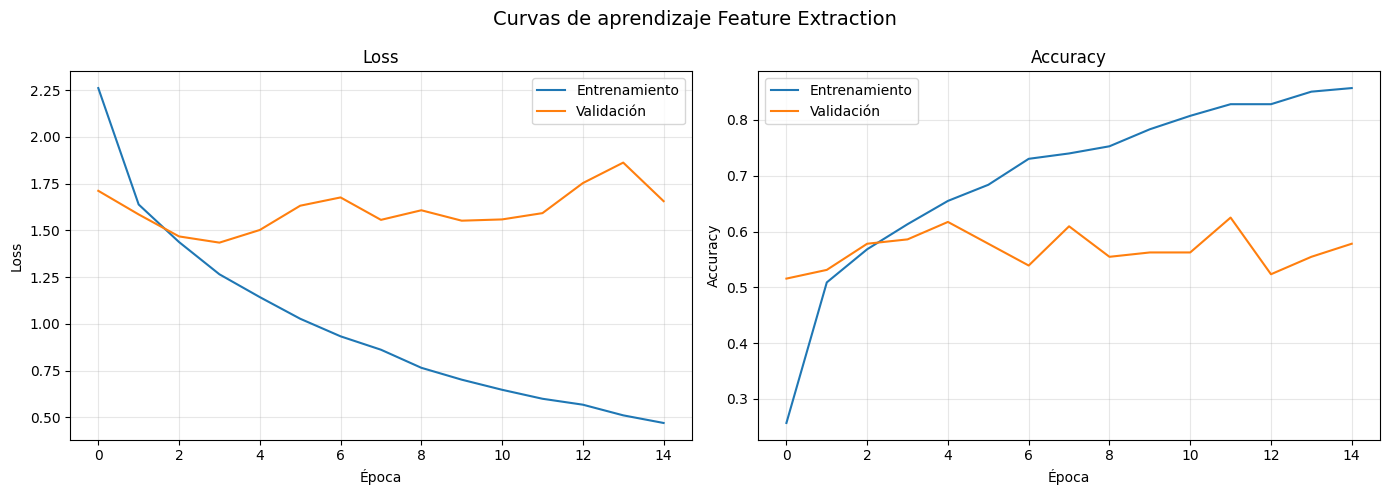

In [151]:
# graficar curvas de pérdida y precisión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(fe_history.history['loss'], label='Entrenamiento')
ax1.plot(fe_history.history['val_loss'], label='Validación')
ax1.set_title('Loss')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(fe_history.history['accuracy'], label='Entrenamiento')
ax2.plot(fe_history.history['val_accuracy'], label='Validación')
ax2.set_title('Accuracy')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Curvas de aprendizaje Feature Extraction', fontsize=14)
plt.tight_layout()
plt.show()

Lsd gráficas del modelo también enseñan como el modelo se iba sobreajustando a medida que aumenta el número de épocas.

In [152]:
# obtener el accuracy en test
test_loss, test_acc = feature_extraction_model.evaluate(test_ds_norm)
print(f'Accuracy en el conjunto de prueba: {test_acc}')

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 991ms/step - accuracy: 0.5290 - loss: 1.8440
Accuracy en el conjunto de prueba: 0.5289855003356934


Ahora, se entrena el modelo con fine-tuning descongelando las últimas 30 capas del modelo base.

In [153]:
# descongelar las últimas 30 capas del modelo base
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

# definir el mismo modelo con un nombre diferente
fine_tuning_model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
], name='fine_tuning_model')

# contar parámetros entrenables
trainable_count = sum(p.numpy().size for p in fine_tuning_model.trainable_weights)
total_count = sum(p.numpy().size for p in fine_tuning_model.weights)

# summary del modelo
fine_tuning_model.summary()

Model: "fine_tuning_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 1,691,658 (6.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

In [154]:
# recompilar con learning rate bajo
fine_tuning_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Entrenando con Fine-Tuning...')
ft_history = fine_tuning_model.fit(
    train_ds_norm,
    validation_data=val_ds_norm,
    epochs=15,
    verbose=1
)

Entrenando con Fine-Tuning...
Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 787ms/step - accuracy: 0.1027 - loss: 2.7363 - val_accuracy: 0.1172 - val_loss: 2.4593
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.1348 - loss: 2.5254 - val_accuracy: 0.1406 - val_loss: 2.4184
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.1605 - loss: 2.4263 - val_accuracy: 0.1172 - val_loss: 2.3559
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.1926 - loss: 2.2704 - val_accuracy: 0.1719 - val_loss: 2.2362
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.2632 - loss: 2.1751 - val_accuracy: 0.2109 - val_loss: 2.1986
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.2777 - loss: 2.0828 - val_accuracy: 0.2188 - val_loss: 2.1931
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.3130 - loss: 1.9728 - val_accuracy: 0.2500 - val_loss: 2.1663
Epoch 8/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.3708 - loss: 1

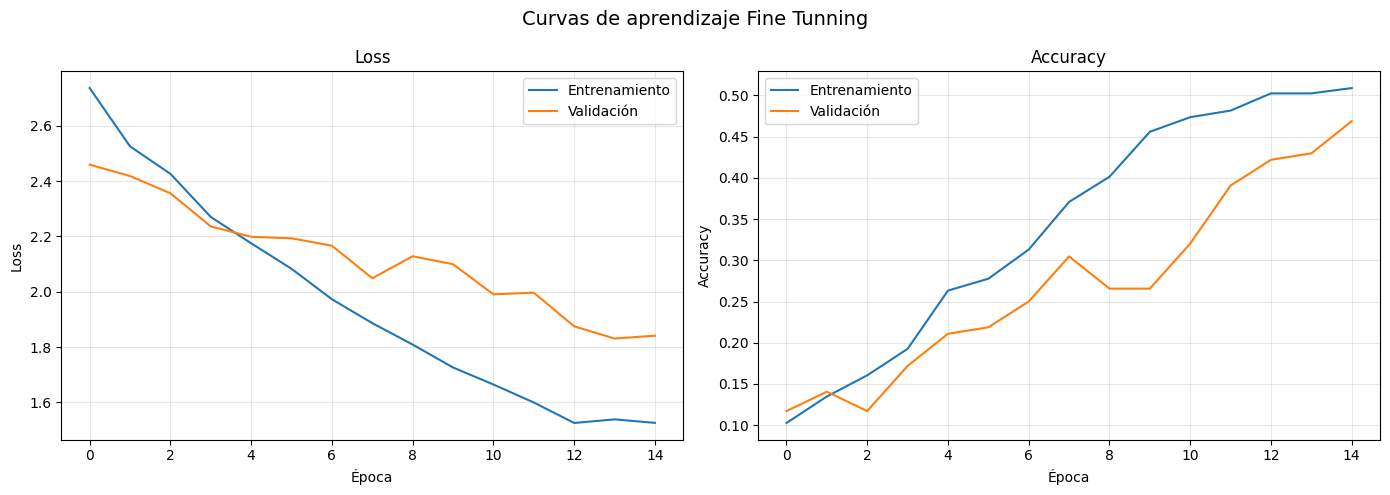

In [155]:
# graficar curvas de pérdida y precisión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ft_history.history['loss'], label='Entrenamiento')
ax1.plot(ft_history.history['val_loss'], label='Validación')
ax1.set_title('Loss')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(ft_history.history['accuracy'], label='Entrenamiento')
ax2.plot(ft_history.history['val_accuracy'], label='Validación')
ax2.set_title('Accuracy')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Curvas de aprendizaje Fine Tunning', fontsize=14)
plt.tight_layout()
plt.show()

In [156]:
# obtener el accuracy en test
test_loss, test_acc = fine_tuning_model.evaluate(test_ds_norm)
print(f'Accuracy en el conjunto de prueba: {test_acc}')

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 860ms/step - accuracy: 0.4203 - loss: 1.8504
Accuracy en el conjunto de prueba: 0.4202898442745209


### 5. Comparación de resultados (15%)

1. Genera la **matriz de confusión** para ambos modelos (CNN y Transfer Learning).
2. Reporta la **precisión (accuracy)**, **precision por clase** y **recall por clase** para ambos modelos.
3. ¿El modelo con transfer learning supera al CNN entrenado desde cero? ¿Por qué crees que sucede esto?
4. ¿Cuáles especies de mariposa son más difíciles de clasificar en cada modelo?


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


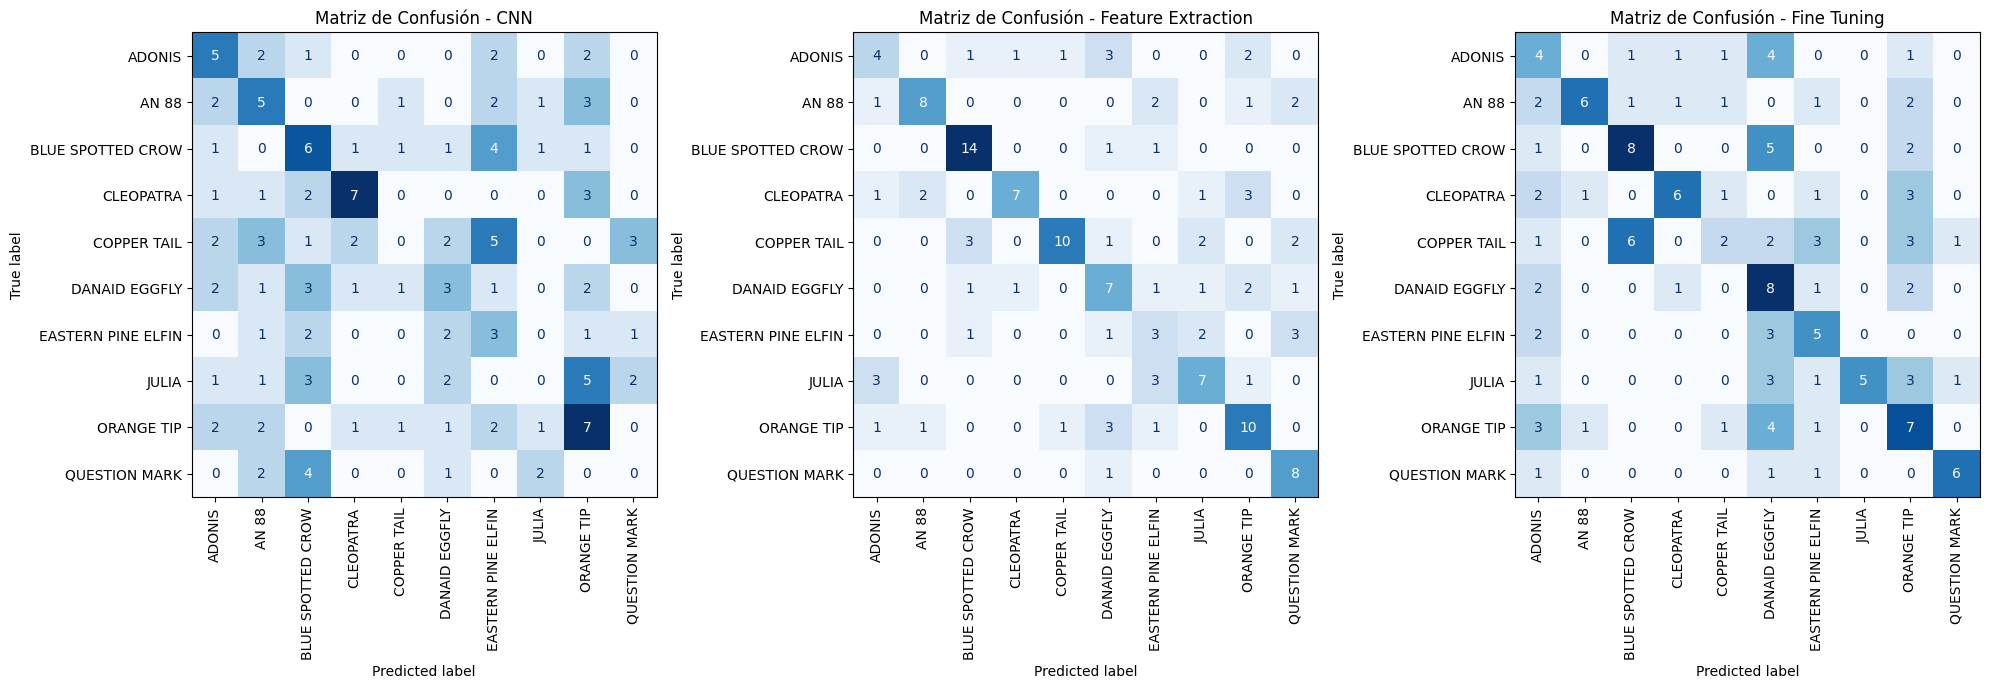

In [157]:
# evaluación del modelo - matriz de confusión
y_true = []
y_pred_cnn = []
y_pred_fe = []
y_pred_ft = []
for images, labels in test_ds_norm:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_cnn.extend(np.argmax(cnn_model.predict(images), axis=1))
    y_pred_fe.extend(np.argmax(feature_extraction_model.predict(images), axis=1))
    y_pred_ft.extend(np.argmax(fine_tuning_model.predict(images), axis=1))

cm_cnn = confusion_matrix(y_true, y_pred_cnn)
cm_fe = confusion_matrix(y_true, y_pred_fe)
cm_ft = confusion_matrix(y_true, y_pred_ft)
disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=class_names,)
disp_fe = ConfusionMatrixDisplay(confusion_matrix=cm_fe, display_labels=class_names,)
disp_ft = ConfusionMatrixDisplay(confusion_matrix=cm_ft, display_labels=class_names,)

# plot
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
disp_cnn.plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title('Matriz de Confusión - CNN', fontsize=12)
disp_fe.plot(ax=axes[1], cmap='Blues', values_format='d', colorbar=False)
axes[1].set_title('Matriz de Confusión - Feature Extraction', fontsize=12)
disp_ft.plot(ax=axes[2], cmap='Blues', values_format='d', colorbar=False)
axes[2].set_title('Matriz de Confusión - Fine Tuning', fontsize=12)

# rotacion de los ejes en los tres subplots y eliminar barra del heatmap
for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=90)
    ax.grid(False)


plt.tight_layout()
plt.show()

In [158]:
# obtener los reportes de clasificación
print('Reporte de clasificación - CNN:')
print(classification_report(y_true, y_pred_cnn, target_names=class_names))
print('='*80)
print('Reporte de clasificación - Feature Extraction:')
print(classification_report(y_true, y_pred_fe, target_names=class_names))
print('='*80)
print('Reporte de clasificación - Fine Tuning:')
print(classification_report(y_true, y_pred_ft, target_names=class_names))

Reporte de clasificación - CNN:
                    precision    recall  f1-score   support

            ADONIS       0.31      0.42      0.36        12
             AN 88       0.28      0.36      0.31        14
 BLUE SPOTTED CROW       0.27      0.38      0.32        16
         CLEOPATRA       0.58      0.50      0.54        14
       COPPER TAIL       0.00      0.00      0.00        18
     DANAID EGGFLY       0.25      0.21      0.23        14
EASTERN PINE ELFIN       0.16      0.30      0.21        10
             JULIA       0.00      0.00      0.00        14
        ORANGE TIP       0.29      0.41      0.34        17
     QUESTION MARK       0.00      0.00      0.00         9

          accuracy                           0.26       138
         macro avg       0.21      0.26      0.23       138
      weighted avg       0.22      0.26      0.23       138

Reporte de clasificación - Feature Extraction:
                    precision    recall  f1-score   support

            ADONI

**Preguntas:**
1. ¿El modelo con transfer learning supera al CNN entrenado desde cero? ¿Por qué crees que sucede esto?

    Efectivamente, el modelo con Feature Extraction supera significativamente al modelo CNN entrenado desde 0. El modelo CNN alcanza un 26% de accuracy, mientras que el modelo con Feature Extraction logra subirla hasta 52%. En este caso particular, el Fine-Tuning baja la métrica a 42%.

    Este efecto puede deberse a que el conocimiento previo de MobileNetv2 contiene pesos que ya son capaces de detectar estructuras fundamentales, como pueden ser bordes, patrones de colores o simetrías, que son de gran importancia para lograr una correcta identificación de mariposas. Además, entrenar una CNN desde cero requiere una cantidad de datos significativa para que los filtros aprendan a extraer características útiles. Con el volumen de imágenes que se trabaja en este ejercicio es posible que no se esté produciendo dicha extracción de características, lo que se evidencia en recalls muy bajos para varias clases.

    Con respecto a los resultados del Fine-Tuning, esto puede deberse a que, al descongelar un número de capas considerable con un conjunto de datos pequeño, en lugar de realizar el ajusto fino de las características, los gradientes pudieron distorsionar los pesos del modelo pre entrenado, lo que empeora la capacidad de generalización en el set de prueba.

2. ¿Cuáles especies de mariposa son más difíciles de clasificar en cada modelo?

- Modelo CNN (Desde cero): Las clases más difíciles son COPPER TAIL (F1: 0.00), JULIA (F1: 0.00) y QUESTION MARK (F1: 0.00), las cuales el modelo no logra identificar en absoluto. También presenta una dificultad crítica la especie EASTERN PINE ELFIN (F1: 0.21).
- Modelo Feature Extraction: Las mariposas más difíciles de clasificar para este modelo son EASTERN PINE ELFIN (F1: 0.29), ADONIS (F1: 0.36) y DANAID EGGFLY (F1: 0.45).

- Modelo Fine Tuning: En este caso, las clases con mayor dificultad para el modelo son COPPER TAIL (F1: 0.17), ADONIS (F1: 0.26) y ORANGE TIP (F1: 0.35).

In [2]:
!jupyter nbconvert --to html "e.laverdeb@uniandes.edu.co_lab9.ipynb"  --output "e.laverdeb@uniandes.edu.co_lab9.html" 

[NbConvertApp] Converting notebook e.laverdeb@uniandes.edu.co_lab9.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 3280459 bytes to e.laverdeb@uniandes.edu.co_lab9.html
